# Used Car Price Analysis

## Project Overview

This project focuses on analyzing a used car dataset to identify the key factors that influence car selling prices.

The analysis will follow a complete Exploratory Data Analysis (EDA) workflow, starting from understanding and inspecting the dataset, followed by data cleaning, feature engineering, univariate analysis, bivariate analysis, and multivariate analysis.

The final goal is to extract meaningful insights from the data and understand the relationships between car characteristics and their selling prices.

### EDA Workflow

The project will follow these main steps:

1. Data Inspection
2. Data Cleaning
3. Feature Engineering
4. Univariate Analysis
5. Bivariate Analysis
6. Multivariate Analysis
7. Final Insights

A dashboard may also be developed as an additional part of the project to provide an interactive way to explore the findings.

## 1. Import Libraries

In this section, we import the Python libraries that will be used throughout the analysis.

- **NumPy** will be used for numerical operations.
- **Pandas** will be used for data manipulation and analysis.
- **Matplotlib** will be used to create visualizations.
- **Seaborn** will be used to create statistical visualizations.

These libraries provide the main tools required to inspect, clean, analyze, and visualize the dataset.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In this section, we load the used car dataset into a Pandas DataFrame.

A DataFrame allows us to work with the dataset in a structured tabular format and provides useful functions for data inspection, cleaning, and analysis.

In [5]:
df = pd.read_csv("car_data.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,NaN,70000.0,Petrrol,NaN,Manual,First Owner
1,Maruti Wagon R LXI Minor,NaN,135000.0,50000.0,Petorl,Indvidual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Deisel,Indvidual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petorl,Indivudal,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesl,Indivudal,Manual,Second Owner


## 3. Dataset Dimensions

Before starting the analysis, it is important to understand the size of the dataset.

We will check the number of rows and columns to determine how many observations and features are available for analysis.

In [6]:
df.shape

(4345, 8)

## 4. Data Inspection

Before cleaning the dataset, we need to inspect its structure and understand the type and quality of the available data.

In this section, we will examine:

- The first few records of the dataset.
- The last few records of the dataset.
- The column names.
- The data types of each column.
- The number of non-null values.
- The overall structure of the DataFrame.

This initial inspection helps us identify potential data quality issues before applying any cleaning techniques.

In [7]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,NaN,70000.0,Petrrol,NaN,Manual,First Owner
1,Maruti Wagon R LXI Minor,NaN,135000.0,50000.0,Petorl,Indvidual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Deisel,Indvidual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petorl,Indivudal,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesl,Indivudal,Manual,Second Owner


In [8]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4340,NaN,2010.0,165000.0,80000.0,NaN,Indvidual,Manual,First Owner
4341,Renault KWID RXT BSIV,2019.0,250000.0,27000.0,NaN,Indvidual,Manual,First Owner
4342,Hyundai Santro Xing GL Plus,2008.0,120000.0,41723.0,Petorl,Indvidual,Manual,Second Owner
4343,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Deisel,Indvidual,Manual,Second Owner
4344,Mahindra TUV 300 T8 AMT,2016.0,730000.0,60000.0,Diesl,Indivudal,Automatic,Second Owner


In [9]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4017 non-null   str    
 1   year           4041 non-null   float64
 2   selling_price  4054 non-null   float64
 3   km_driven      4026 non-null   str    
 4   fuel           4042 non-null   str    
 5   seller_type    4056 non-null   str    
 6   transmission   4040 non-null   str    
 7   owner          4059 non-null   str    
dtypes: float64(2), str(6)
memory usage: 526.6 KB


## 5. Missing Values Analysis

Missing values are an important part of data quality assessment.

In this section, we will identify the number of missing values in each column and calculate their percentage relative to the total number of records.

Understanding the distribution of missing values will help us decide how they should be handled during the data cleaning stage.

In [11]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing Percentage
name,328,7.548907
km_driven,319,7.341772
transmission,305,7.019563
year,304,6.996548
fuel,303,6.973533
selling_price,291,6.697353
seller_type,289,6.651323
owner,286,6.582278


## 6. Duplicate Records

Duplicate records can affect the accuracy of our analysis because the same observation may be counted more than once.

Therefore, we will check whether the dataset contains duplicated rows before moving to the data cleaning stage.

In [12]:
df.duplicated().sum()

np.int64(112)

## 7. Unique Values in Categorical Features

We will inspect the unique values of the categorical features to identify inconsistencies, spelling variations, unexpected categories, or missing values.

This step is especially important before cleaning categorical data because different values may represent the same category.

In [13]:
categorical_columns = ["fuel", "seller_type", "transmission", "owner"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


fuel:
fuel
Diesl       1013
Deisel       987
Petrrol      682
Petrl        677
Petorl       619
NaN          303
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

seller_type:
seller_type
Indivudal           1531
Indvidual           1503
Deelar               476
Dealerr              452
NaN                  289
Trustmark Dealer      94
Name: count, dtype: int64

transmission:
transmission
Manual       3611
Automatic     429
NaN           305
Name: count, dtype: int64

owner:
owner
First Owner             2654
Second Owner            1035
NaN                      286
Third Owner              280
Fourth & Above Owner      73
Test Drive Car            17
Name: count, dtype: int64


## 8. Statistical Summary of Numerical Features

In this section, we will examine the statistical summary of the numerical features in the dataset.

This will help us understand the central tendency, spread, and range of the numerical variables and may also help us identify potential unusual values or outliers.

The main statistics include:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [14]:
df.describe()

,year,selling_price
count,4041.000000,4.054000e+03
mean,2013.276417,5.026554e+05
std,16.556865,5.804930e+05
min,1800.000000,-1.200000e+05
25%,2011.000000,2.000000e+05
50%,2014.000000,3.500000e+05
75%,2016.000000,6.000000e+05
max,3000.000000,8.900000e+06


## 9. Detailed Categorical Value Inspection

We will inspect the unique values in all categorical features.

This allows us to identify inconsistent labels, spelling errors, unexpected categories, and other data quality issues before cleaning the dataset.

In [15]:
categorical_columns = ["fuel", "seller_type", "transmission", "owner"]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{column.upper()}")
    print(f"{'=' * 50}")
    print(df[column].value_counts(dropna=False))


FUEL
fuel
Diesl       1013
Deisel       987
Petrrol      682
Petrl        677
Petorl       619
NaN          303
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

SELLER_TYPE
seller_type
Indivudal           1531
Indvidual           1503
Deelar               476
Dealerr              452
NaN                  289
Trustmark Dealer      94
Name: count, dtype: int64

TRANSMISSION
transmission
Manual       3611
Automatic     429
NaN           305
Name: count, dtype: int64

OWNER
owner
First Owner             2654
Second Owner            1035
NaN                      286
Third Owner              280
Fourth & Above Owner      73
Test Drive Car            17
Name: count, dtype: int64


## 10. Data Cleaning

After completing the initial inspection, several data quality issues were identified, including:

- Missing values
- Duplicate records
- Inconsistent categorical labels
- Incorrect data types
- Invalid numerical values
- Potential outliers

We will now clean the dataset while preserving the original dataset for reference.

A separate copy will be created so that the raw data remains unchanged.

In [16]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Original shape: (4345, 8)
Working copy shape: (4345, 8)


### 10.1 Standardizing Column Names

We will standardize the column names to make them consistent, readable, and easier to work with throughout the analysis.

In [17]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

### 10.2 Correcting Data Types

Some numerical variables are stored using an incorrect data type.

The `km_driven` column is currently stored as a string even though it represents numerical distance values.

We will convert it to a numeric data type. Invalid values will be converted to missing values so they can be handled appropriately later.

In [18]:
df_clean["km_driven"] = pd.to_numeric(
    df_clean["km_driven"],
    errors="coerce"
)

df_clean[["year", "selling_price", "km_driven"]].dtypes

year             float64
selling_price    float64
km_driven        float64
dtype: object

### 10.3 Removing Duplicate Records

The initial inspection identified duplicated rows in the dataset.

Duplicate records can cause certain observations to be counted more than once and may distort our analysis.

Therefore, exact duplicate rows will be removed.

In [19]:
duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicates_before)
print("New dataset shape:", df_clean.shape)

Duplicates removed: 112
New dataset shape: (4233, 8)


### 10.4 Standardizing Categorical Values

The categorical features contain spelling inconsistencies where multiple labels represent the same category.

For example, the `fuel` column contains variations such as `Petrrol`, `Petrol`, and `Petorl`.

Similarly, the `seller_type` column contains variations such as `Indvidual` and `Indivudal`.

These inconsistencies would cause the same category to be treated as different groups during analysis.

Therefore, we will standardize these labels into consistent categories.

In [20]:
# Standardize fuel categories
fuel_mapping = {
    "Petrrol": "Petrol",
    "Petorl": "Petrol",
    "Petrl": "Petrol",
    "Diesl": "Diesel",
    "Deisel": "Diesel"
}

df_clean["fuel"] = df_clean["fuel"].replace(fuel_mapping)


# Standardize seller type categories
seller_mapping = {
    "Indvidual": "Individual",
    "Indivudal": "Individual",
    "Deelar": "Dealer",
    "Dealerr": "Dealer"
}

df_clean["seller_type"] = df_clean["seller_type"].replace(seller_mapping)

### 10.5 Verifying Categorical Cleaning

After standardizing the categorical values, we will verify the remaining categories to make sure that the inconsistent labels have been successfully corrected.

In [21]:
for column in ["fuel", "seller_type", "transmission", "owner"]:
    print(f"\n{column.upper()}")
    print(df_clean[column].value_counts(dropna=False))


FUEL
fuel
Petrol      1940
Diesel      1931
NaN          299
CNG           39
LPG           23
Electric       1
Name: count, dtype: int64

SELLER_TYPE
seller_type
Individual          2998
Dealer               877
NaN                  289
Trustmark Dealer      69
Name: count, dtype: int64

TRANSMISSION
transmission
Manual       3530
Automatic     399
NaN           304
Name: count, dtype: int64

OWNER
owner
First Owner             2562
Second Owner            1019
NaN                      284
Third Owner              278
Fourth & Above Owner      73
Test Drive Car            17
Name: count, dtype: int64


### 10.6 Handling Invalid Numerical Values

During the statistical inspection, we identified suspicious numerical values.

A selling price cannot logically be negative, so negative values in `selling_price` will be treated as invalid and converted to missing values.

The `year` column also contains an unrealistic value such as 1800. Since the dataset represents modern used vehicles, years outside a reasonable range will be treated as invalid.

Converting invalid values to missing values allows us to handle them consistently during the missing-value treatment stage.

In [22]:
# Invalid selling prices
df_clean.loc[df_clean["selling_price"] < 0, "selling_price"] = np.nan

# Invalid vehicle years
df_clean.loc[
    (df_clean["year"] < 1980) | (df_clean["year"] > 2026),
    "year"
] = np.nan

print("Invalid values handled successfully.")

Invalid values handled successfully.


### 10.7 Data Quality Check After Initial Cleaning

We will perform another quality check to evaluate the dataset after handling duplicates, data types, inconsistent categories, and invalid numerical values.

This allows us to confirm that the cleaning steps were applied successfully before handling the remaining missing values.

In [23]:
print("Shape:", df_clean.shape)
print("\nData Types:")
print(df_clean.dtypes)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Shape: (4233, 8)

Data Types:
name                 str
year             float64
selling_price    float64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

Missing Values:
name             326
year             307
selling_price    293
km_driven        323
fuel             299
seller_type      289
transmission     304
owner            284
dtype: int64

Duplicate Rows:
201


## 11. Handling Missing Values

After the initial cleaning process, missing values are still present across all features.

The appropriate treatment depends on the nature of each variable.

For numerical features such as `year`, `selling_price`, and `km_driven`, the median will be considered because it is less sensitive to extreme values than the mean.

For categorical features, the mode will be used to fill missing values because it represents the most frequently occurring category.

For the `name` feature, missing values will be labeled as `"Unknown"` because the vehicle name is categorical and replacing it with the most common vehicle name would introduce incorrect information.

In [24]:
# Fill missing values in numerical columns with the median
numerical_columns = ["year", "selling_price", "km_driven"]

for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())


# Fill missing values in categorical columns with the mode
categorical_columns = ["fuel", "seller_type", "transmission", "owner"]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])


# Handle missing vehicle names
df_clean["name"] = df_clean["name"].fillna("Unknown")

## 12. Removing Duplicate Records After Standardization

After standardizing categorical values and handling missing values, some records may become identical.

We will perform a final duplicate check and remove any remaining exact duplicate rows to ensure that each observation is represented only once.

In [25]:
duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicates_before)
print("Final shape:", df_clean.shape)

Duplicates removed: 307
Final shape: (3926, 8)


## 13. Final Data Quality Check

Before starting the exploratory analysis, we will perform a final validation of the cleaned dataset.

We will verify:

- Dataset dimensions
- Missing values
- Duplicate records
- Data types
- Basic statistical information

The dataset should now be consistent and ready for analysis.

In [27]:
print("Final Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

Final Shape: (3926, 8)

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows:
0

Data Types:
name                 str
year             float64
selling_price    float64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object


## 14. Feature Engineering

Feature engineering involves creating new variables from existing data to make the dataset more informative for analysis.

For this project, we will create a `car_age` feature based on the vehicle's manufacturing year.

Car age can provide a more intuitive representation of vehicle age and may help us better understand its relationship with the selling price.

We will use 2026 as the reference year.

In [28]:
df_clean["car_age"] = 2026 - df_clean["year"]

df_clean[["year", "car_age"]].head()

,year,car_age
0,2007.0,19.0
1,2014.0,12.0
2,2012.0,14.0
3,2017.0,9.0
4,2014.0,12.0


### 14.1 Price per Kilometer

We will create a `price_per_km` feature to provide an additional perspective on the relationship between a vehicle's selling price and its driven distance.

This feature should be interpreted carefully because it is a derived metric and may be affected by very low or high mileage values.

In [29]:
df_clean["price_per_km"] = (
    df_clean["selling_price"] / df_clean["km_driven"]
)

df_clean[["selling_price", "km_driven", "price_per_km"]].head()

,selling_price,km_driven,price_per_km
0,350000.0,70000.0,5.000000
1,135000.0,50000.0,2.700000
2,600000.0,100000.0,6.000000
3,250000.0,46000.0,5.434783
4,450000.0,141000.0,3.191489


## 15. Univariate Analysis

Univariate analysis focuses on examining one variable at a time.

The purpose of this section is to understand the distribution, central tendency, spread, and potential outliers of the numerical features.

We will analyze the distributions of:

- Selling Price
- Kilometers Driven
- Car Age
- Price per Kilometer

In [30]:
numerical_columns = [
    "selling_price",
    "km_driven",
    "car_age",
    "price_per_km"
]

df_clean[numerical_columns].describe()

,selling_price,km_driven,car_age,price_per_km
count,3.926000e+03,3.926000e+03,3926.000000,3926.000000
mean,4.751266e+05,8.843434e+04,12.891238,85.862235
std,5.195587e+05,8.572078e+05,4.073420,3990.940513
min,2.000000e+04,1.000000e+00,6.000000,0.005400
25%,2.150000e+05,4.000000e+04,10.000000,2.727273
50%,3.500000e+05,6.000000e+04,12.000000,5.833333
75%,5.700000e+05,9.000000e+04,15.000000,13.333333
max,8.900000e+06,5.000000e+07,34.000000,250000.000000


### 15.1 Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables.

They help us identify whether the data is approximately normally distributed, skewed, concentrated around specific values, or affected by extreme observations.

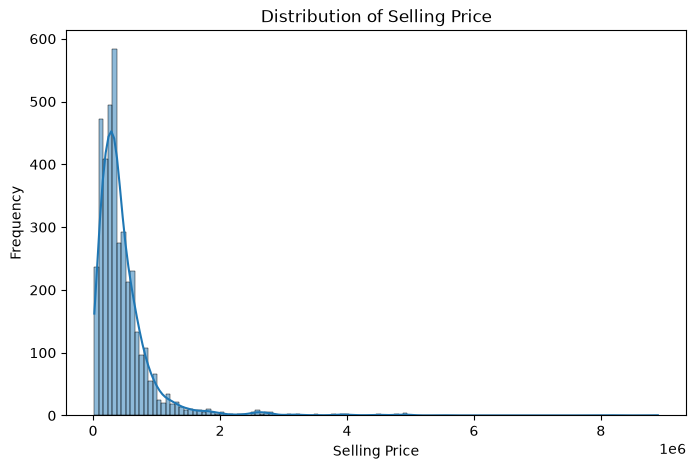

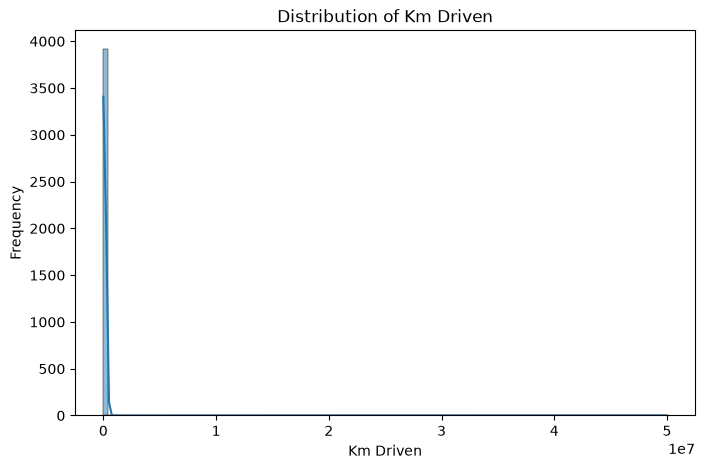

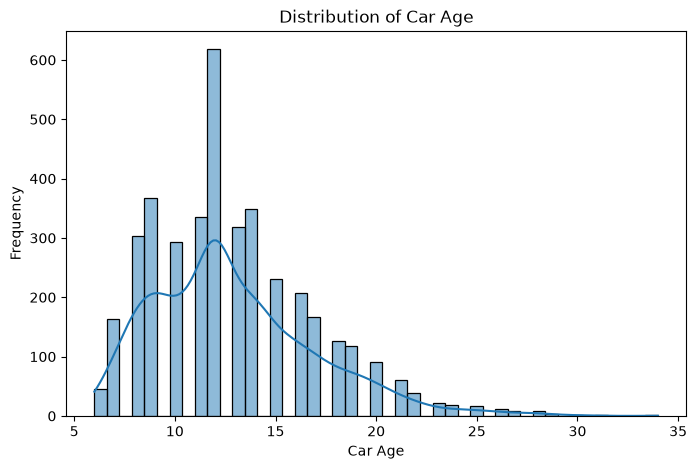

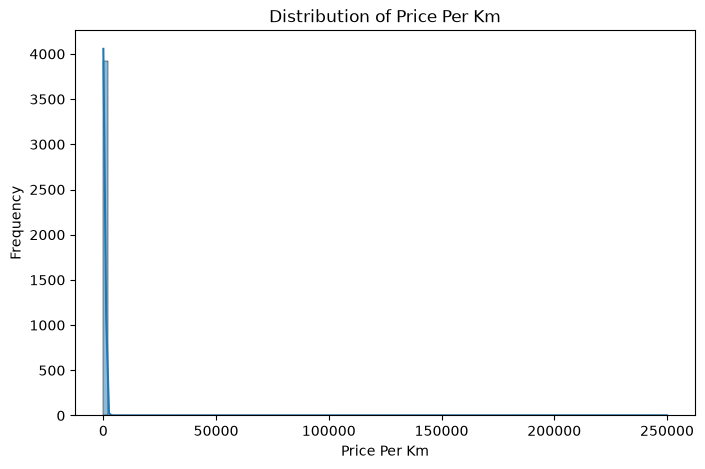

In [31]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_clean, x=column, kde=True)
    plt.title(f"Distribution of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.show()

### 15.2 Outlier Detection

Boxplots provide a visual way to identify the spread of numerical variables and detect potential outliers.

Outliers will not automatically be removed. They will first be investigated to determine whether they represent errors or legitimate observations.

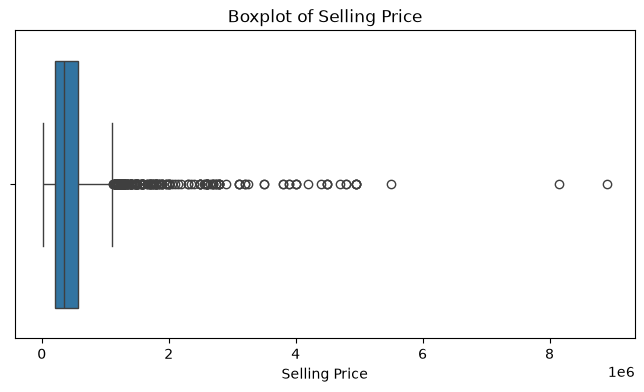

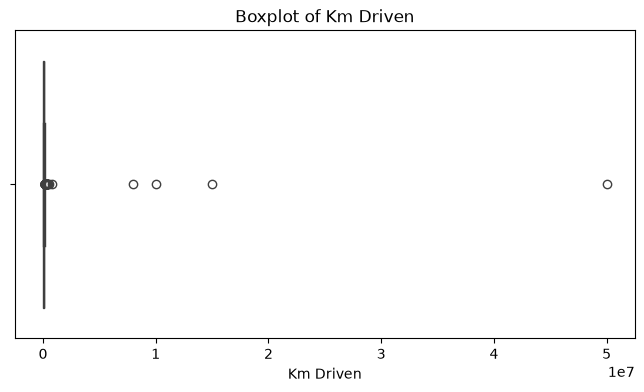

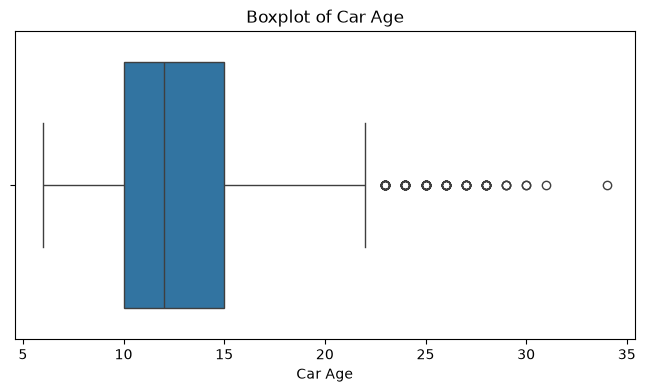

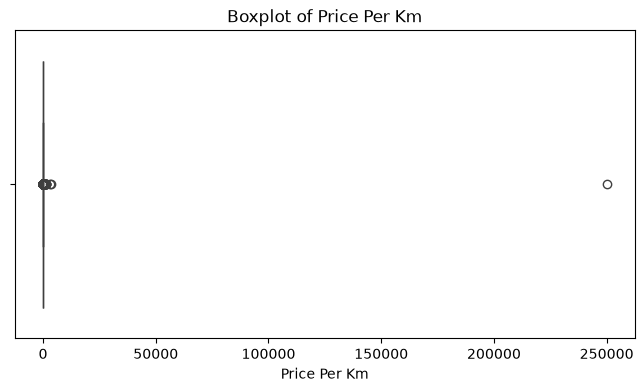

In [32]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[column])
    plt.title(f"Boxplot of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())
    plt.show()

## 16. Categorical Variables Analysis

We will now analyze the distribution of the categorical features.

Bar charts will be used to understand the frequency of each category and identify the most common characteristics among the vehicles in the dataset.

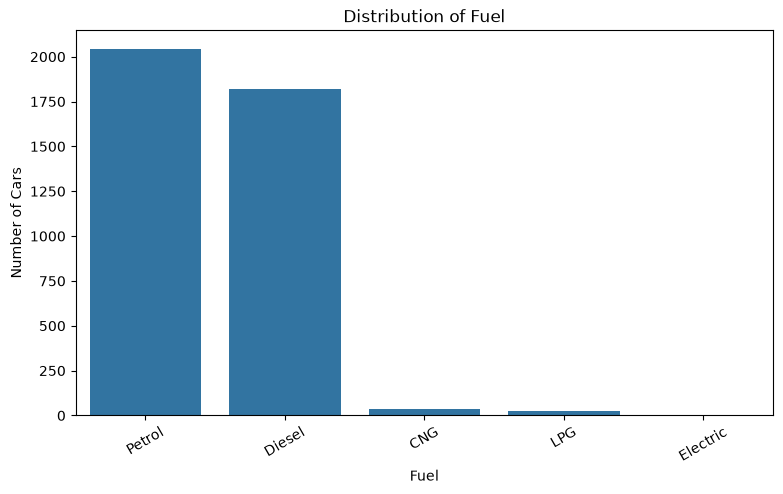

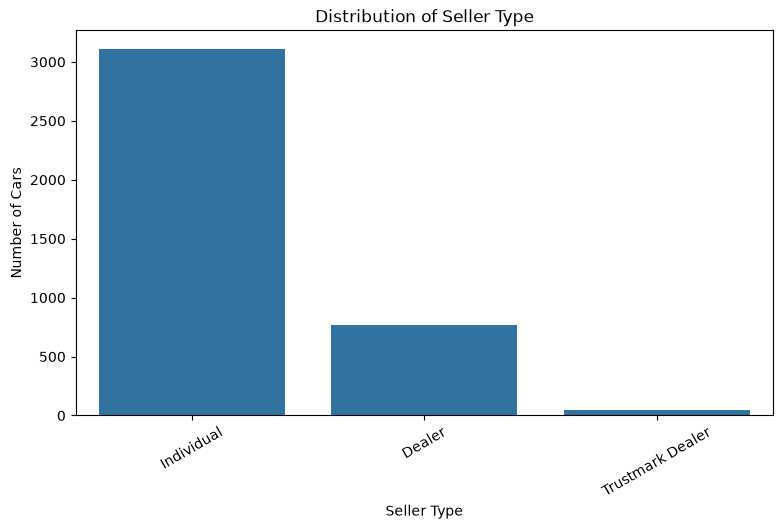

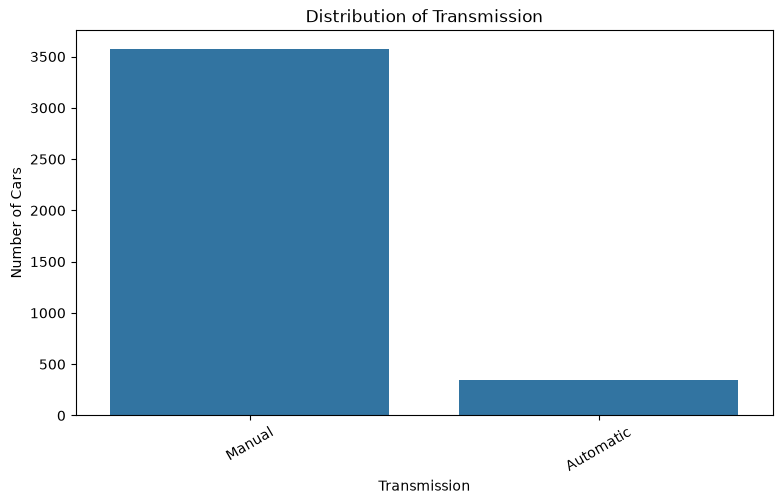

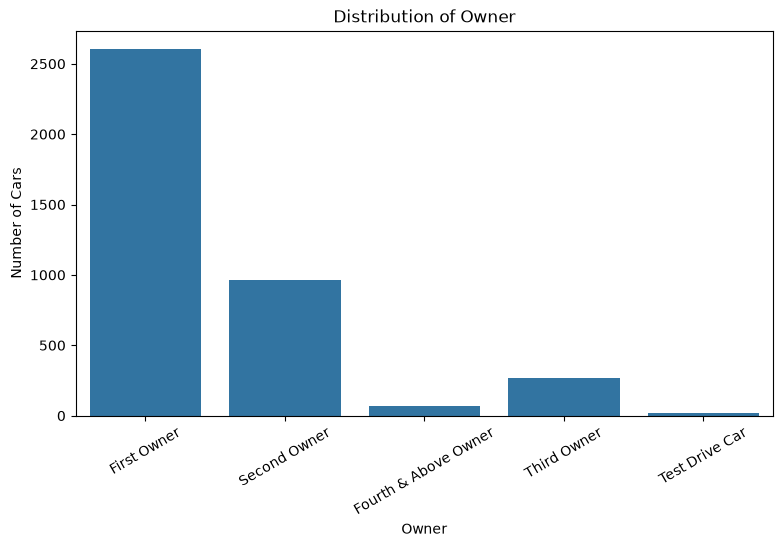

In [33]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_columns:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df_clean, x=column)
    plt.title(f"Distribution of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Number of Cars")
    plt.xticks(rotation=30)
    plt.show()

## 17. Outlier Investigation

The univariate analysis revealed several extreme values, particularly in `selling_price`, `km_driven`, and `price_per_km`.

However, the presence of an outlier does not automatically mean that the observation is incorrect.

Before removing any observations, we will investigate the extreme values and determine whether they represent valid observations, data entry errors, or values created by the structure of a derived feature.

This step helps us avoid removing potentially useful information without sufficient evidence.

In [34]:
# Inspect the highest values of the numerical features

for column in ["selling_price", "km_driven", "price_per_km"]:
    print(f"\n{'=' * 50}")
    print(f"Top 10 values for {column}")
    print(f"{'=' * 50}")
    print(df_clean[["name", "year", "selling_price", "km_driven", "price_per_km"]]
          .sort_values(by=column, ascending=False)
          .head(10))


Top 10 values for selling_price
                                                   name    year  \
3530           Audi RS7 2015-2019 Sportback Performance  2014.0   
80    Mercedes-Benz S-Class S 350d Connoisseurs Edition  2017.0   
3619            Mercedes-Benz GLS 2016-2020 350d 4MATIC  2016.0   
2499                            BMW X5 xDrive 30d xLine  2019.0   
577                             BMW X5 xDrive 30d xLine  2019.0   
559                             BMW X5 xDrive 30d xLine  2019.0   
544                             BMW X5 xDrive 30d xLine  2019.0   
3136                      BMW 5 Series 520d Luxury Line  2018.0   
3540                      BMW 5 Series 520d Luxury Line  2019.0   
885                                   Audi A5 Sportback  2020.0   

      selling_price  km_driven  price_per_km  
3530      8900000.0    60000.0    148.333333  
80        8150000.0     6500.0   1253.846154  
3619      5500000.0    77350.0     71.105365  
2499      4950000.0    60000.0     82.500

### 17.1 Investigating Extremely Low Mileage

The `price_per_km` feature contains extremely large values.

Since this feature is calculated by dividing selling price by kilometers driven, very small mileage values can produce unusually high ratios.

We will inspect records with very low mileage to determine whether these values are plausible or likely to be data quality issues.

In [35]:
df_clean[
    ["name", "year", "selling_price", "km_driven", "price_per_km"]
].sort_values(
    by="km_driven",
    ascending=True
).head(15)

,name,year,selling_price,km_driven,price_per_km
1218,Mahindra Quanto C6,2014.0,250000.0,1.0,250000.000000
1606,Unknown,2020.0,350000.0,101.0,3465.346535
3374,Ford EcoSport 1.5 Diesel Trend BSIV,2018.0,841000.0,1000.0,841.000000
1197,Maruti Alto 800 VXI,2020.0,350000.0,1000.0,350.000000
1633,Renault Duster 85PS Diesel RxL,2013.0,350000.0,1000.0,350.000000
541,Renault Duster 85PS Diesel RxL,2013.0,450000.0,1000.0,450.000000
2008,Ford Ecosport Sports Petrol,2020.0,1100000.0,1000.0,1100.000000
852,Renault Duster 85PS Diesel RxL,2014.0,450000.0,1000.0,450.000000
3871,Honda Amaze S Petrol BSIV,2014.0,614000.0,1000.0,614.000000
2153,Unknown,2020.0,541000.0,1000.0,541.000000


### 17.2 Identifying Statistical Outliers Using IQR

The Interquartile Range (IQR) method will be used to identify potential statistical outliers.

The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1).

Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

These observations will be identified for investigation rather than automatically removed.

In [36]:
outlier_summary = []

for column in ["selling_price", "km_driven", "car_age", "price_per_km"]:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df_clean) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,selling_price,215000.000000,570000.000000,355000.000000,-317500.000000,1.102500e+06,221,5.629139
1,km_driven,40000.000000,90000.000000,50000.000000,-35000.000000,1.650000e+05,122,3.107489
2,car_age,10.000000,15.000000,5.000000,2.500000,2.250000e+01,91,2.317881
3,price_per_km,2.727273,13.333333,10.606061,-13.181818,2.924242e+01,476,12.124300


### 17.3 Investigating Extreme Mileage Values

The `km_driven` feature contains several extreme observations, including a maximum value of 50,000,000 km.

Such a value appears unrealistic for a used passenger vehicle and may indicate a data entry error.

Instead of removing all statistical outliers, we will inspect the most extreme mileage values and identify clearly implausible observations.

In [37]:
df_clean[
    ["name", "year", "selling_price", "km_driven", "fuel", "owner"]
].sort_values(
    by="km_driven",
    ascending=False
).head(20)

,name,year,selling_price,km_driven,fuel,owner
1957,Datsun RediGO S,2016.0,270000.0,50000000.0,Petrol,First Owner
3634,Maruti Zen LX,2014.0,85000.0,15000000.0,Petrol,Second Owner
3275,Mahindra Scorpio VLX 2WD AIRBAG BSIV,2014.0,600000.0,9999999.0,Diesel,Second Owner
3823,Honda City i-DTEC VX,2017.0,1000000.0,8000000.0,Diesel,First Owner
1149,Maruti Swift VXI BSIII,2009.0,250000.0,806599.0,Petrol,First Owner
514,Maruti SX4 S Cross DDiS 320 Delta,2016.0,665000.0,560000.0,Diesel,First Owner
3352,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006.0,400000.0,400000.0,Diesel,Third Owner
2187,Toyota Innova 2.5 V Diesel 8-seater,2009.0,350000.0,350000.0,Diesel,First Owner
60,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010.0,280000.0,350000.0,Diesel,Second Owner
3389,Toyota Innova 2.5 GX 8 STR BSIV,2009.0,420000.0,347089.0,Petrol,First Owner


### 17.4 Mileage Range Analysis

To better understand the mileage distribution, we will examine selected percentiles.

Percentiles provide a clearer view of the typical mileage range while reducing the influence of extreme observations.

In [38]:
df_clean["km_driven"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
)

0.500       60000.00
0.750       90000.00
0.900      120000.00
0.950      140000.00
0.990      222858.75
0.995      260125.00
1.000    50000000.00
Name: km_driven, dtype: float64

### 17.5 Handling Clearly Invalid Mileage Values

The investigation identified four extremely large mileage values above 1,000,000 km.

These values are considered clearly implausible for the type of passenger vehicles represented in this dataset and are likely the result of data-entry errors.

We will replace these invalid values with missing values and then impute them using the median mileage.

Other high-mileage observations will be retained because they may represent legitimate high-usage vehicles.

In [39]:
# Identify clearly invalid mileage values
invalid_mileage = df_clean["km_driven"] > 1_000_000

print("Invalid mileage records:", invalid_mileage.sum())

# Replace invalid values with NaN
df_clean.loc[invalid_mileage, "km_driven"] = np.nan

# Impute with median
df_clean["km_driven"] = df_clean["km_driven"].fillna(
    df_clean["km_driven"].median()
)

print("\nMaximum mileage after cleaning:",
      df_clean["km_driven"].max())

Invalid mileage records: 4

Maximum mileage after cleaning: 806599.0


### 17.6 Recalculating Derived Features

Since `km_driven` was corrected, the previously calculated `price_per_km` values may no longer be accurate.

We will recalculate `price_per_km` using the cleaned mileage values to ensure that the derived feature is consistent with the final dataset.

In [40]:
df_clean["price_per_km"] = (
    df_clean["selling_price"] / df_clean["km_driven"]
)

df_clean[["selling_price", "km_driven", "price_per_km"]].head()

,selling_price,km_driven,price_per_km
0,350000.0,70000.0,5.000000
1,135000.0,50000.0,2.700000
2,600000.0,100000.0,6.000000
3,250000.0,46000.0,5.434783
4,450000.0,141000.0,3.191489


## 18. Final Outlier Check

After investigating and correcting clearly invalid values, we will review the numerical features again.

The goal is not to eliminate every statistical outlier, but to ensure that the remaining extreme observations are reasonable and potentially meaningful for analysis.

In [41]:
df_clean[[
    "selling_price",
    "km_driven",
    "car_age",
    "price_per_km"
]].describe()

,selling_price,km_driven,car_age,price_per_km
count,3.926000e+03,3926.000000,3926.000000,3926.000000
mean,4.751266e+05,67354.357616,12.891238,85.870484
std,5.195587e+05,45196.626189,4.073420,3990.940349
min,2.000000e+04,1.000000,6.000000,0.250000
25%,2.150000e+05,40000.000000,10.000000,2.727273
50%,3.500000e+05,60000.000000,12.000000,5.833333
75%,5.700000e+05,90000.000000,15.000000,13.333333
max,8.900000e+06,806599.000000,34.000000,250000.000000


# 19. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

In this section, we will investigate how different vehicle characteristics are related to the selling price.

The main questions we aim to answer are:

- Does vehicle age affect selling price?
- Does mileage affect selling price?
- Does fuel type affect selling price?
- Does transmission type affect selling price?
- Does seller type affect selling price?
- Does the number of previous owners affect selling price?

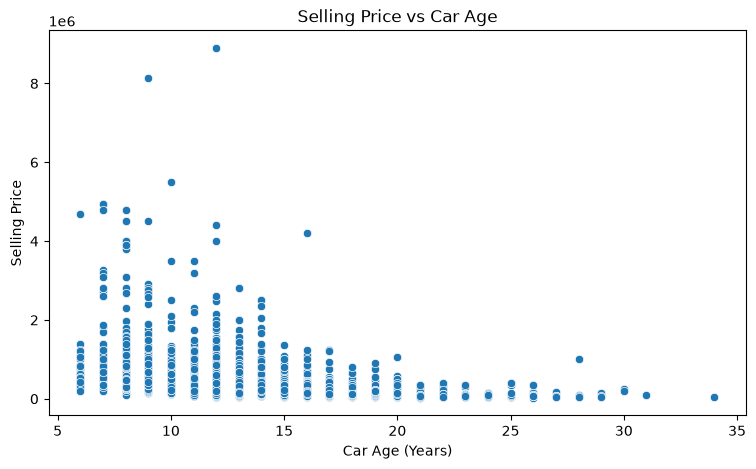

In [42]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="car_age",
    y="selling_price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

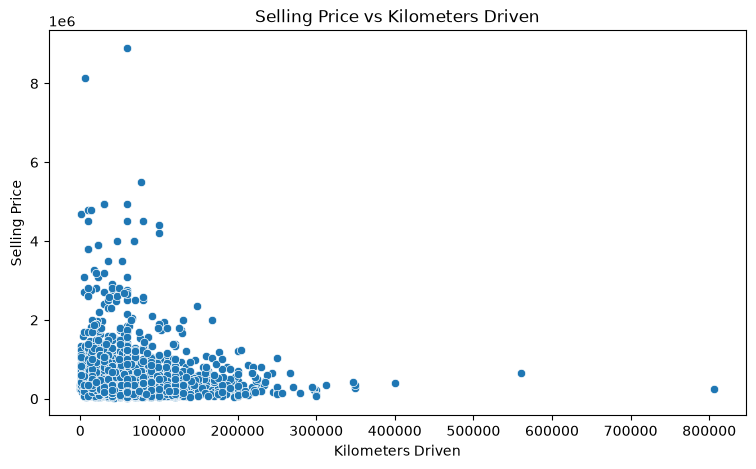

In [43]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price"
)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

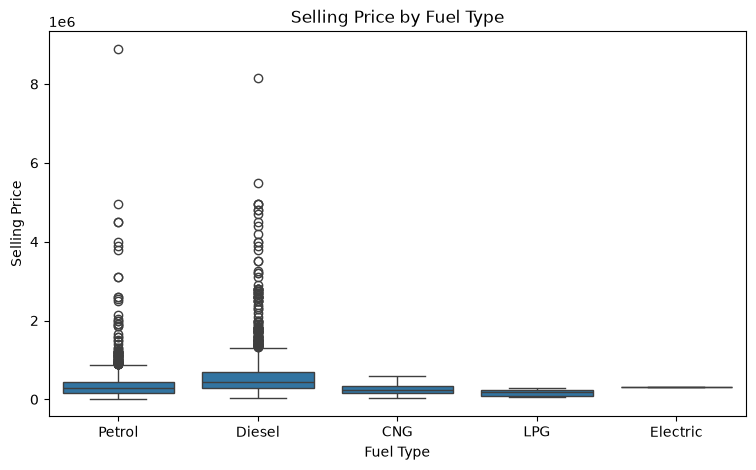

In [44]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

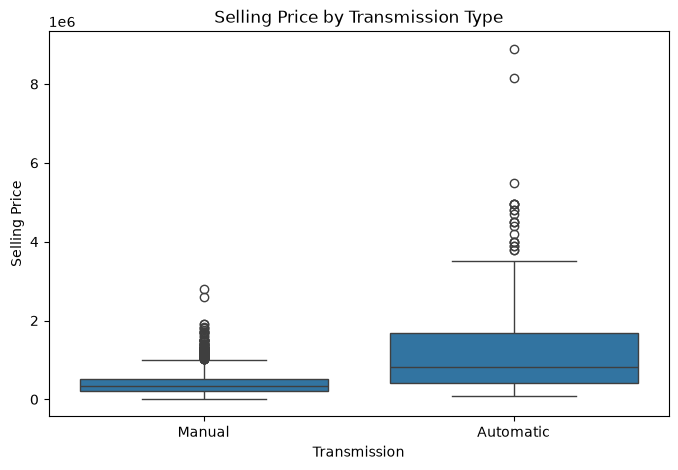

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

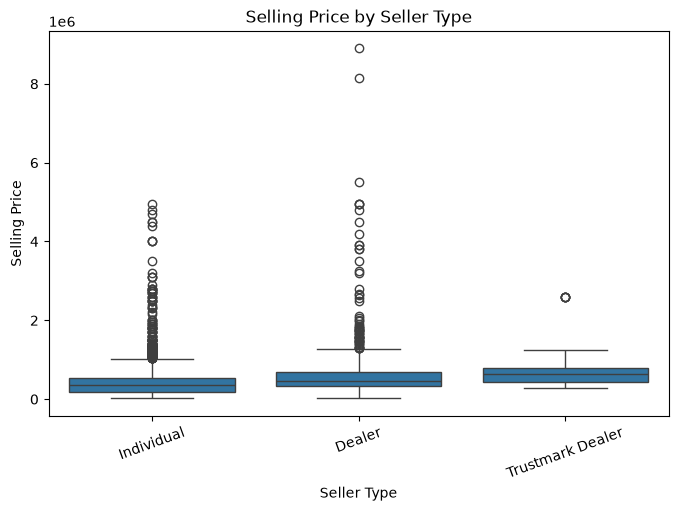

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=20)
plt.show()

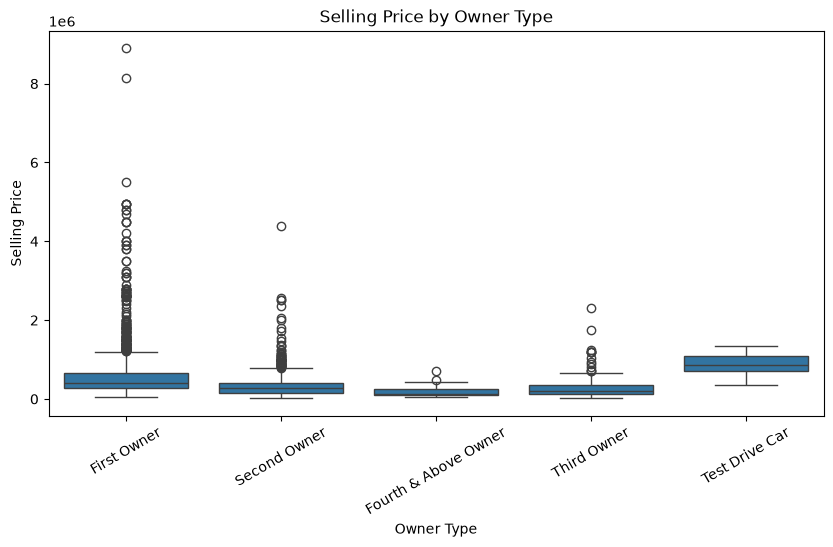

In [47]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="owner",
    y="selling_price"
)

plt.title("Selling Price by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=30)
plt.show()

### 19.1 Correlation Analysis

Correlation analysis is used to measure the strength and direction of the linear relationship between numerical variables.

In this section, we will examine the relationships between selling price, vehicle age, and kilometers driven.

The correlation coefficient ranges from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak linear relationship.

Correlation does not imply causation.

In [48]:
correlation_columns = [
    "selling_price",
    "km_driven",
    "car_age"
]

correlation_matrix = df_clean[correlation_columns].corr()

correlation_matrix

,selling_price,km_driven,car_age
selling_price,1.000000,-0.167586,-0.388780
km_driven,-0.167586,1.000000,0.379251
car_age,-0.388780,0.379251,1.000000


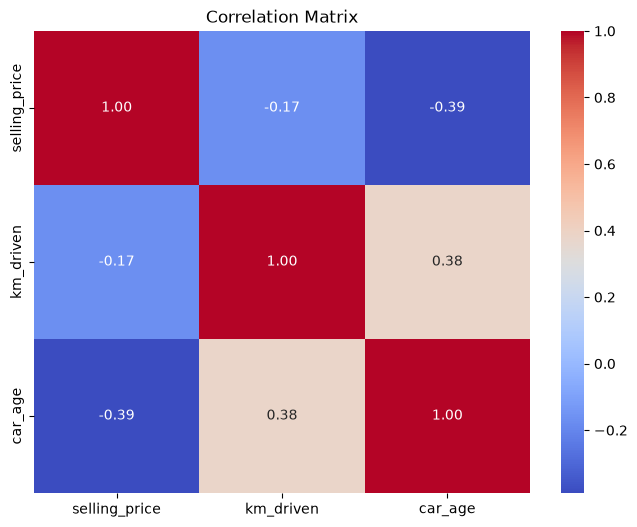

In [49]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### 19.2 Average Selling Price by Categorical Features

We will compare the average selling price across different categorical groups.

This allows us to identify which vehicle characteristics are associated with higher or lower average selling prices.

In [50]:
categorical_price_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_price_columns:
    avg_price = (
        df_clean.groupby(column)["selling_price"]
        .mean()
        .sort_values(ascending=False)
    )

    print(f"\nAverage Selling Price by {column}:")
    print(avg_price)


Average Selling Price by fuel:
fuel
Diesel      606890.686436
Petrol      364868.995597
Electric    310000.000000
CNG         276675.594595
LPG         167826.043478
Name: selling_price, dtype: float64

Average Selling Price by seller_type:
seller_type
Trustmark Dealer    838020.833333
Dealer              643436.720991
Individual          428031.564770
Name: selling_price, dtype: float64

Average Selling Price by transmission:
transmission
Automatic    1.272049e+06
Manual       3.971281e+05
Name: selling_price, dtype: float64

Average Selling Price by owner:
owner
Test Drive Car          870882.176471
First Owner             552541.882534
Second Owner            337481.772349
Third Owner             272646.125461
Fourth & Above Owner    177830.943662
Name: selling_price, dtype: float64


### 19.3 Median Selling Price by Category

Because selling price contains extreme values, the mean can be strongly affected by expensive vehicles.

Therefore, we will also compare the median selling price across categories to obtain a more robust measure of the typical vehicle price.

In [51]:
for column in categorical_price_columns:
    median_price = (
        df_clean.groupby(column)["selling_price"]
        .median()
        .sort_values(ascending=False)
    )

    print(f"\nMedian Selling Price by {column}:")
    print(median_price)


Median Selling Price by fuel:
fuel
Diesel      450000.0
Electric    310000.0
Petrol      300000.0
CNG         245000.0
LPG         180000.0
Name: selling_price, dtype: float64

Median Selling Price by seller_type:
seller_type
Trustmark Dealer    650000.0
Dealer              450000.0
Individual          350000.0
Name: selling_price, dtype: float64

Median Selling Price by transmission:
transmission
Automatic    810000.0
Manual       350000.0
Name: selling_price, dtype: float64

Median Selling Price by owner:
owner
Test Drive Car          852000.0
First Owner             400000.0
Second Owner            276000.0
Third Owner             210000.0
Fourth & Above Owner    135000.0
Name: selling_price, dtype: float64


# 20. Additional Feature Engineering

The `name` feature contains the full vehicle model name.

To make the dataset more useful for analysis, we will extract the vehicle brand from the beginning of the vehicle name.

This new `brand` feature will allow us to compare vehicle prices across different manufacturers.

In [52]:
df_clean["brand"] = (
    df_clean["name"]
    .str.split()
    .str[0]
)

df_clean[["name", "brand"]].head(10)

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Unknown,Unknown
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


### 20.1 Brand Distribution

We will examine the most common vehicle brands in the dataset.

This helps us understand the composition of the dataset and identify the manufacturers with the largest representation.

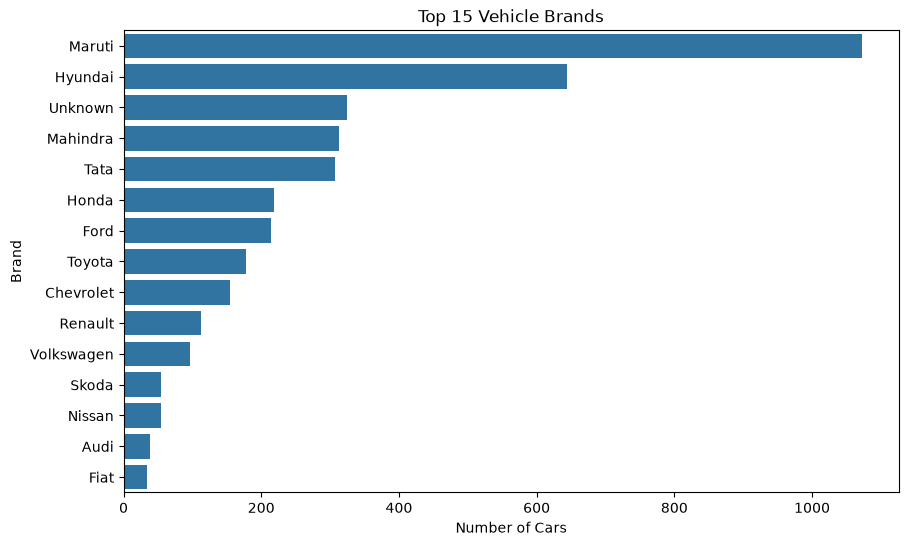

In [53]:
brand_counts = df_clean["brand"].value_counts().head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Top 15 Vehicle Brands")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.show()

### 20.2 Average Selling Price by Brand

We will compare the average selling price of the most represented vehicle brands.

Only brands with sufficient observations will be considered to reduce the effect of very small groups.

In [54]:
brand_stats = (
    df_clean.groupby("brand")
    .agg(
        car_count=("selling_price", "count"),
        average_price=("selling_price", "mean"),
        median_price=("selling_price", "median")
    )
    .query("car_count >= 20")
    .sort_values("average_price", ascending=False)
)

brand_stats.head(15)

,car_count,average_price,median_price
brand,,,
Mercedes-Benz,20,2.511700e+06,1475500.0
BMW,31,2.359355e+06,2200000.0
Audi,38,2.056026e+06,1580000.0
Toyota,178,8.205842e+05,605000.0
Mahindra,313,5.647188e+05,500000.0
Ford,214,5.482009e+05,450000.0
Honda,218,5.316697e+05,475000.0
Volkswagen,97,4.685154e+05,399000.0
Unknown,324,4.596718e+05,350000.0


# 21. Multivariate Analysis

Multivariate analysis examines multiple variables simultaneously.

In this section, we will investigate how vehicle age, mileage, fuel type, and transmission are related to selling price.

Analyzing multiple variables together provides deeper insights than examining each relationship independently.

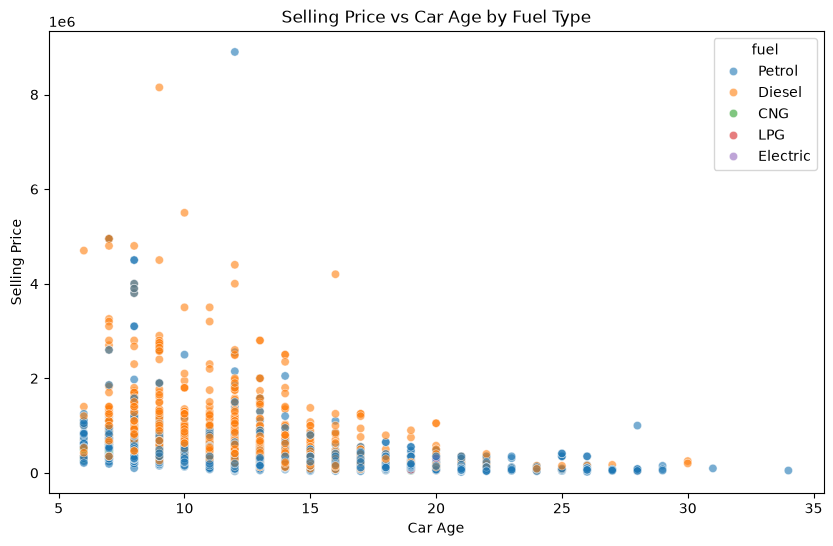

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="car_age",
    y="selling_price",
    hue="fuel",
    alpha=0.6
)

plt.title("Selling Price vs Car Age by Fuel Type")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

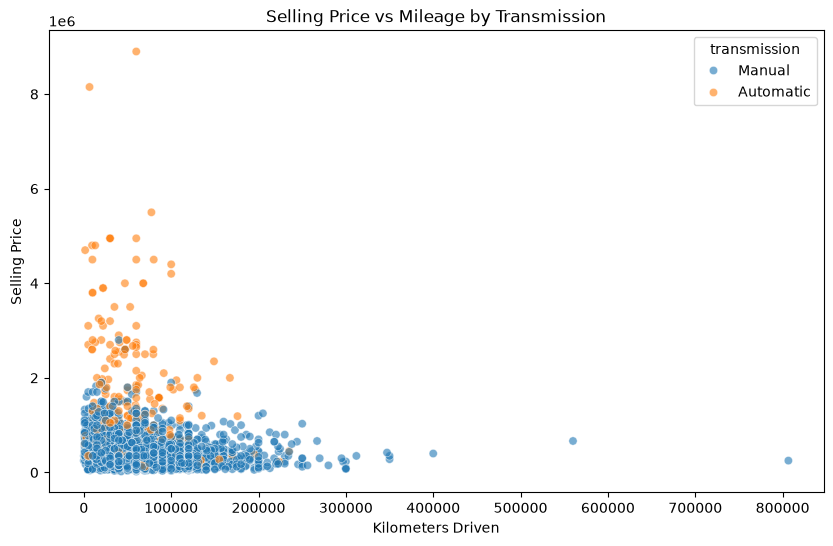

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price",
    hue="transmission",
    alpha=0.6
)

plt.title("Selling Price vs Mileage by Transmission")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

### 21.3 Combined Category Analysis

We will examine the average selling price across combinations of fuel type and transmission.

This provides a more detailed view of how multiple categorical characteristics are associated with vehicle prices.

In [57]:
fuel_transmission_price = (
    df_clean.groupby(["fuel", "transmission"])["selling_price"]
    .mean()
    .unstack()
)

fuel_transmission_price

transmission,Automatic,Manual
fuel,,
CNG,NaN,276675.594595
Diesel,1.640206e+06,493547.191347
Electric,3.100000e+05,NaN
LPG,NaN,167826.043478
Petrol,8.856213e+05,317931.856533


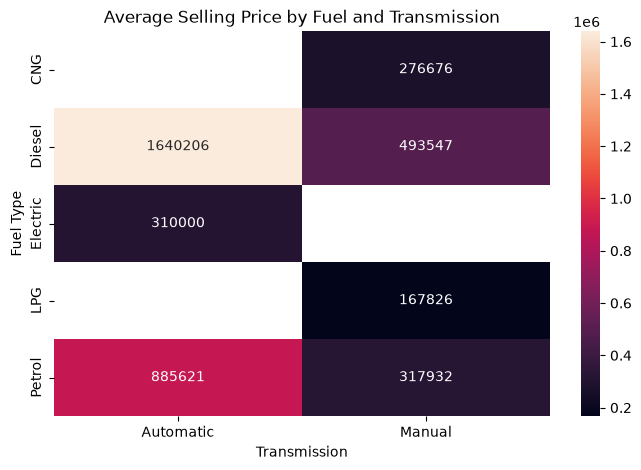

In [58]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    fuel_transmission_price,
    annot=True,
    fmt=".0f"
)

plt.title("Average Selling Price by Fuel and Transmission")
plt.xlabel("Transmission")
plt.ylabel("Fuel Type")
plt.show()

# 22. Final Insights

Based on the exploratory data analysis, several important patterns were identified:

1. **Vehicle Age and Selling Price**
   
   Newer vehicles generally tend to have higher selling prices, while older vehicles tend to have lower resale values.

2. **Mileage and Selling Price**
   
   Higher kilometers driven are generally associated with lower vehicle prices, although the relationship is not perfectly linear.

3. **Price Distribution**
   
   Selling prices are strongly right-skewed, with most vehicles concentrated in the lower and middle price ranges and a smaller number of premium vehicles having substantially higher prices.

4. **Fuel Type**
   
   Petrol and Diesel vehicles represent the vast majority of the dataset. Their price distributions show differences in typical selling prices.

5. **Transmission**
   
   Manual vehicles dominate the dataset, while automatic vehicles represent a much smaller proportion.

6. **Seller Type**
   
   Individual sellers represent the majority of observations, followed by dealers.

7. **Ownership**
   
   First-owner vehicles are the most common group. Vehicles with more previous owners generally tend to have lower resale prices.

8. **Vehicle Brand**
   
   Vehicle brands differ considerably in their average selling prices, indicating that brand and model characteristics are important factors in the used-car market.

9. **Data Quality**
   
   The original dataset contained missing values, duplicate records, inconsistent categorical labels, incorrect data types, and clearly invalid numerical values. These issues were addressed before conducting the main analysis.

# 23. Final Dataset Summary

After completing data cleaning and feature engineering, the dataset is ready for further analysis and visualization.

The final dataset contains cleaned numerical and categorical variables, along with engineered features such as `car_age`, `price_per_km`, and `brand`.

The dataset is now free of missing values and duplicate records and has consistent categorical labels.

In [59]:
print("Final Dataset Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Final Dataset Shape: (3926, 11)

Columns:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'price_per_km', 'brand']

Missing Values:
0

Duplicate Rows:
0


# 24. Exporting the Cleaned Dataset

After completing the data cleaning and feature engineering process, we will export the final dataset into a new CSV file.

The original raw dataset will remain unchanged, while the cleaned dataset will be saved separately for use in the dashboard and future analysis.

In [60]:
df_clean.to_csv("cleaned_car_data.csv", index=False)

print("Cleaned dataset exported successfully.")
print("File: cleaned_car_data.csv")

Cleaned dataset exported successfully.
File: cleaned_car_data.csv


## 25. Verifying the Exported Dataset

We will load the exported file again to verify that the cleaned dataset was saved correctly and that its structure has been preserved.

In [61]:
cleaned_df = pd.read_csv("cleaned_car_data.csv")

print("Shape:", cleaned_df.shape)
print("\nColumns:")
print(cleaned_df.columns.tolist())

print("\nMissing Values:")
print(cleaned_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(cleaned_df.duplicated().sum())

Shape: (3926, 11)

Columns:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'price_per_km', 'brand']

Missing Values:
0

Duplicate Rows:
0
